<a href="https://colab.research.google.com/github/YinkaAjao/-Building-a-Pipeline-for-Time-Series-Data/blob/main/Building_a_Pipeline_for_Time_Series_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Time-series Preprocessing and Exploratory Analysis

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

pd.options.display.float_format = '{:,.2f}'.format

### Dataset Description
The Global Economy Indicators (1970-2021) dataset provides a comprehensive look at macroeconomic trends across 200+ countries. It includes 26 variables, covering GDP, GNI, Population, and sector-specific value additions (like Manufacturing and Agriculture). It is the product of a global cooperation effort between the Economic Statistics Branch of the United Nations Statistics Division, international statistical agencies, and the national statistical services of these countries and is developed in accordance with the recommendation of the Statistical Commission at its first session in 1947 that the Statistics Division should publish regularly the most recent available data on national accounts for as many countries and areas as possible.

We chose this dataset because it fulfills all the requirements of a high-quality time-series project:

**Temporal Depth:** With 52 years of data, it allows for meaningful long-term trend analysis.

**Predictive Complexity:** Predicting GDP is a task that benefits significantly from lagged features (previous years) and moving averages (economic cycles).

**Multivariate Nature:** The presence of population and consumption data allows us to explore correlations that drive the target variable (GDP).

In [86]:
Url = "https://raw.githubusercontent.com/YinkaAjao/-Building-a-Pipeline-for-Time-Series-Data/refs/heads/main/Global%20Economy%20Indicators.csv"
df = pd.read_csv(Url)

# Clean column and country names
df.columns = df.columns.str.strip()
df['Country'] = df['Country'].str.strip()

# Select a specific country for time-series analysis
country_name = "United States"
ts_data = df[df['Country'] == country_name].sort_values('Year')

# Log missing values before handling
missing_pre = ts_data.isnull().sum().sum()
print(f"Missing values found and interpolated: {missing_pre}")

# Handling missing values using Interpolation for economic trends
ts_data = ts_data.infer_objects(copy=False).interpolate(method='linear').ffill().bfill()

# Set Year as index for time-series operations
ts_data.set_index('Year', inplace=True)

Missing values found and interpolated: 2


/tmp/ipykernel_221/1622485629.py:17: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  ts_data = ts_data.infer_objects(copy=False).interpolate(method='linear').ffill().bfill()


## Dataset Overview & Statistical Distribution

* **Time Range:** 1970 to 2021 (52 Years)
* **Frequency/Granularity:** Annual (Yearly)
* **Missing Values Handling:** As macroeconomic variables (like population and GDP) grow continuously, missing values were handled using **Linear Interpolation**. This methodology was selected because it is mathematically much more accurate for trending time-series data than filling gaps with a static mean or zero, which would distort the trend line.

Below is the statistical distribution of our key numerical columns. Understanding these distributions helps us identify skewness in our economic indicators.

Summary Statistics


,Gross Domestic Product (GDP),Population,Final consumption expenditure,Per capita GNI
count,52.00,52.00,52.00,52.00
mean,"9,321,346,153,846.15","268,076,552.38","7,604,865,384,615.38","32,119.44"
std,"6,499,368,002,109.72","43,251,698.86","5,418,868,607,147.01","18,944.10"
min,"1,070,000,000,000.00","200,328,340.00","840,000,000,000.00","5,363.00"
25%,"3,557,500,000,000.00","229,792,827.50","2,817,500,000,000.00","15,462.00"
50%,"7,855,000,000,000.00","267,322,451.50","6,260,000,000,000.00","29,212.50"
75%,"14,575,000,000,000.00","306,399,191.25","12,325,000,000,000.00","48,082.25"
max,"23,300,000,000,000.00","336,997,624.00","19,300,000,000,000.00","70,081.00"


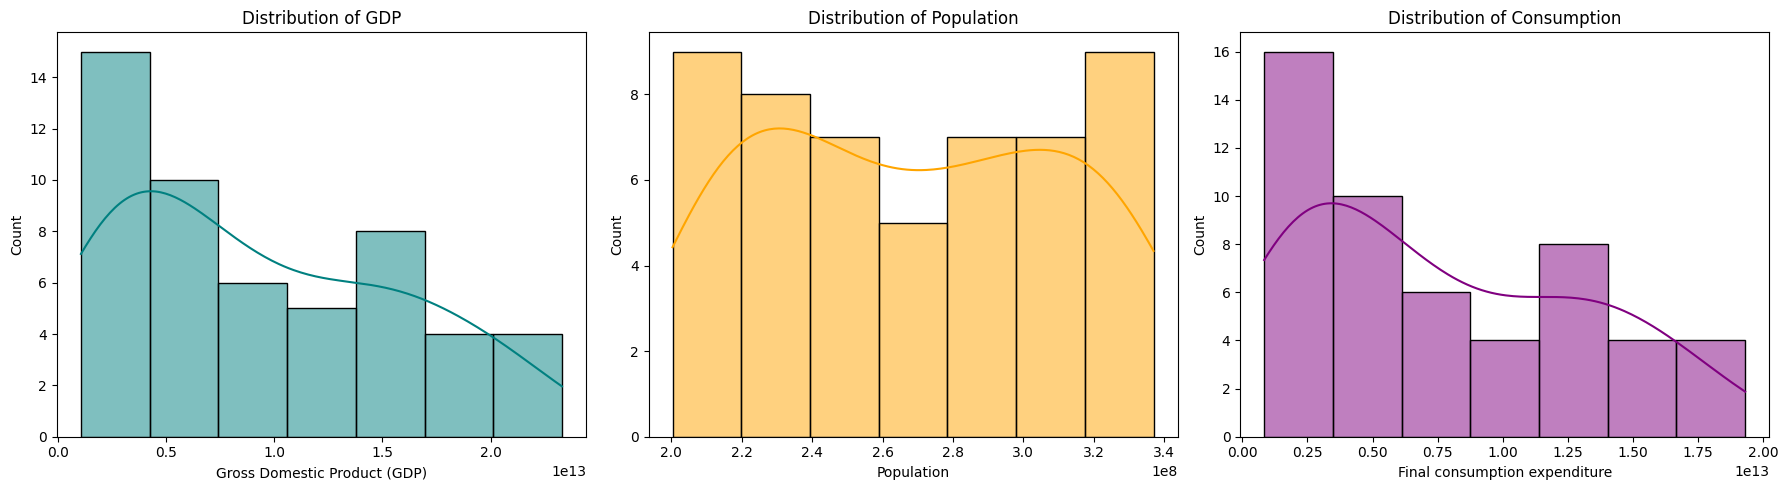

In [87]:
# 1. Display Summary Statistics
print("Summary Statistics")
display(ts_data[['Gross Domestic Product (GDP)', 'Population', 'Final consumption expenditure', 'Per capita GNI']].describe())

# 2. Visualise Statistical Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(ts_data['Gross Domestic Product (GDP)'], kde=True, color='teal', ax=axes[0])
axes[0].set_title('Distribution of GDP')

sns.histplot(ts_data['Population'], kde=True, color='orange', ax=axes[1])
axes[1].set_title('Distribution of Population')

sns.histplot(ts_data['Final consumption expenditure'], kde=True, color='purple', ax=axes[2])
axes[2].set_title('Distribution of Consumption')

plt.tight_layout()
plt.show()

## Time-Series Feature Engineering
To fulfill the requirement of utilizing lagged features and moving averages, we engineered two new variables prior to our exploratory analysis:
1. **GDP_Lag1 (Lagged Feature):** This shifts the GDP data down by one year. It allows us to ask the model: "Given the GDP of the previous year, what will the GDP be this year?"
2. **GDP_5Year_MA (Moving Average):** This calculates the rolling mean over a 5-year window.

In [88]:
ts_data['GDP_Lag1'] = ts_data['Gross Domestic Product (GDP)'].shift(1)

ts_data['GDP_5Year_MA'] = ts_data['Gross Domestic Product (GDP)'].rolling(window=5).mean()

# Note: We do not drop NaNs just yet so we can visualize the full timeline in EDA

Our First question was: Does the GDP show a consistent increasing trend over the decades?

**Aim:** We need to check if our data is stable over time or if it’s actually trending upward or downward. This matters because the forecasting method we choose will depend entirely on whether there’s a trend to account for.

**Interpretation:** The series shows a strong upward exponential trend, with visible dips during known global recessions (e.g., 2008, 2020).

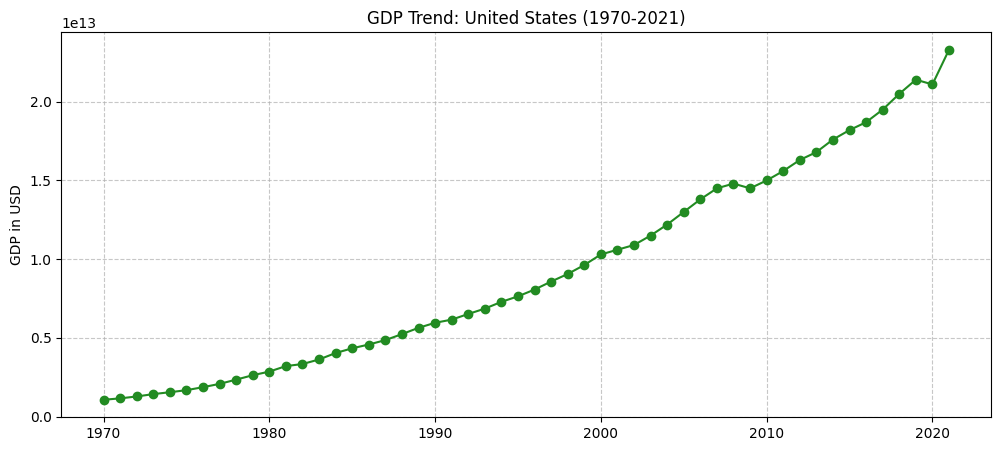

In [89]:
plt.figure(figsize=(12, 5))
plt.plot(ts_data['Gross Domestic Product (GDP)'], marker='o', color='forestgreen')
plt.title(f'GDP Trend: {country_name} (1970-2021)')
plt.ylabel('GDP in USD')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Our Second question was: How does the 5-Year Moving Average smooth out economic volatility?

**Aim:** To visualize how a rolling average reduces the "noise" of year-to-year economic shocks, making the underlying, long-term economic cycle easier for a predictive model to focus on.

**Interpretation:** The 5-year moving average successfully filters out short-term fluctuations. The red line highlights the long-term growth trajectory, proving it is a stable feature for forecasting.

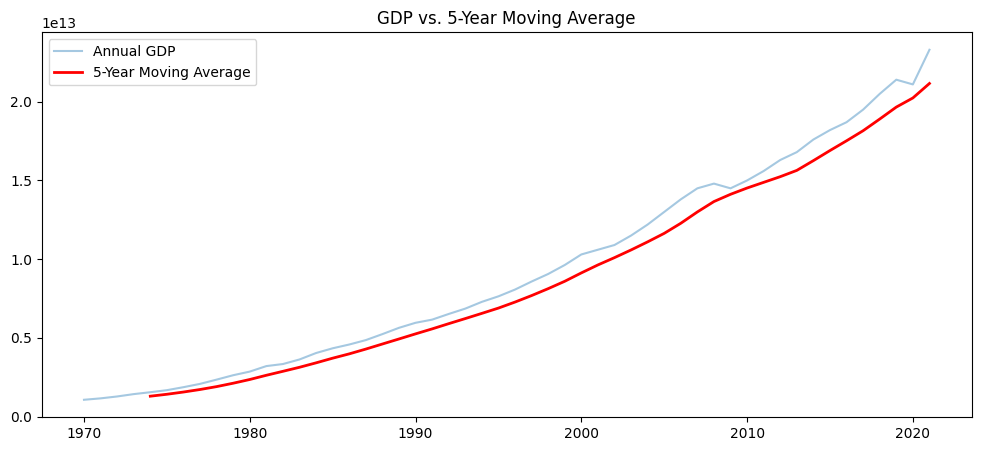

In [90]:
ts_data['GDP_5Year_MA'] = ts_data['Gross Domestic Product (GDP)'].rolling(window=5).mean()

plt.figure(figsize=(12, 5))
plt.plot(ts_data['Gross Domestic Product (GDP)'], label='Annual GDP', alpha=0.4)
plt.plot(ts_data['GDP_5Year_MA'], label='5-Year Moving Average', color='red', linewidth=2)
plt.title('GDP vs. 5-Year Moving Average')
plt.legend()
plt.show()

Our Third question was: Is last year's GDP a strong predictor for the current year?

**Aim:** To test the series for "autocorrelation" (the correlation of a signal with a delayed copy of itself). If autocorrelation is high, lagged features are highly valuable for machine learning models.

**Interpretation:** The extremely tight linear alignment of the scatter points proves a near-perfect positive correlation. This confirms that the GDP is highly autocorrelated. Basically, the strongest predictor of a country's economic output today is its economic output yesterday.

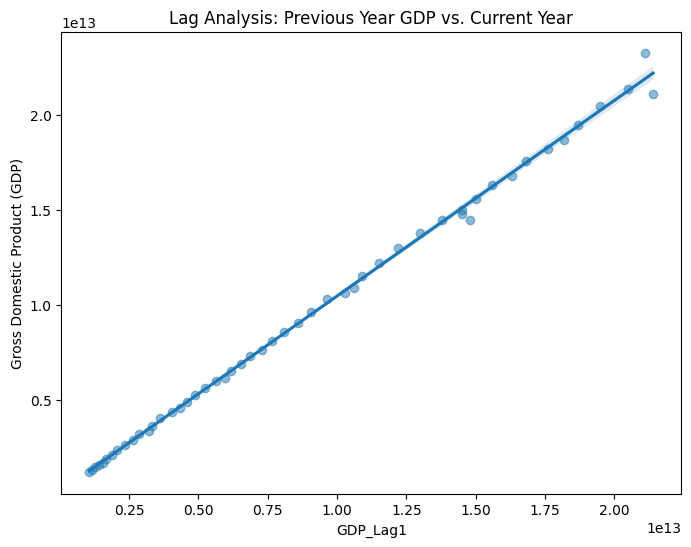

In [91]:
ts_data['GDP_Lag1'] = ts_data['Gross Domestic Product (GDP)'].shift(1)

plt.figure(figsize=(8, 6))
sns.regplot(x='GDP_Lag1', y='Gross Domestic Product (GDP)', data=ts_data, scatter_kws={'alpha':0.5})
plt.title('Lag Analysis: Previous Year GDP vs. Current Year')
plt.show()

Our Fourth question was: Which variables correlate most strongly with GDP growth?

**Aim:** We're going to narrow down our list of potential predictors by figuring out which outside factors actually move in sync with what we're trying to forecast. If there's a strong linear connection, that variable makes the cut.

**Interpretation:** "Final consumption expenditure" shows a near-perfect correlation with GDP, suggesting it is the primary driver of the domestic economy. Population also shows a very strong correlation, indicating that economic output scales heavily with population growth.

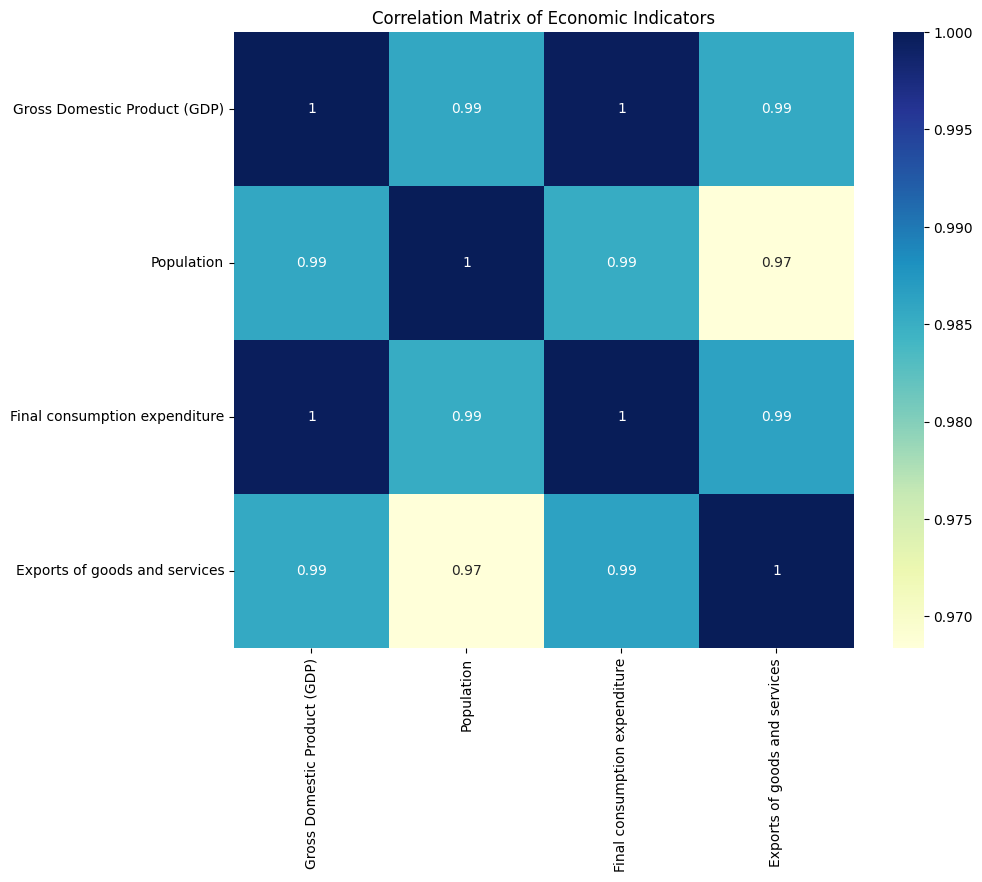

In [92]:
plt.figure(figsize=(10, 8))
corr_cols = ['Gross Domestic Product (GDP)', 'Population', 'Final consumption expenditure', 'Exports of goods and services']
sns.heatmap(ts_data[corr_cols].corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation Matrix of Economic Indicators')
plt.show()

Our Fifth question was: How has the GDP per capita evolved relative to population growth?

**Aim:** To understand if the total GDP growth is purely a byproduct of having more citizens, or if individual productivity and wealth are also increasing over time.

**Interpretation:** While both metrics are rising, GNI per capita follows a much steeper curve in recent decades compared to the linear growth of the population. This indicates a significant increase in per-capita productivity and overall wealth, independent of population size.

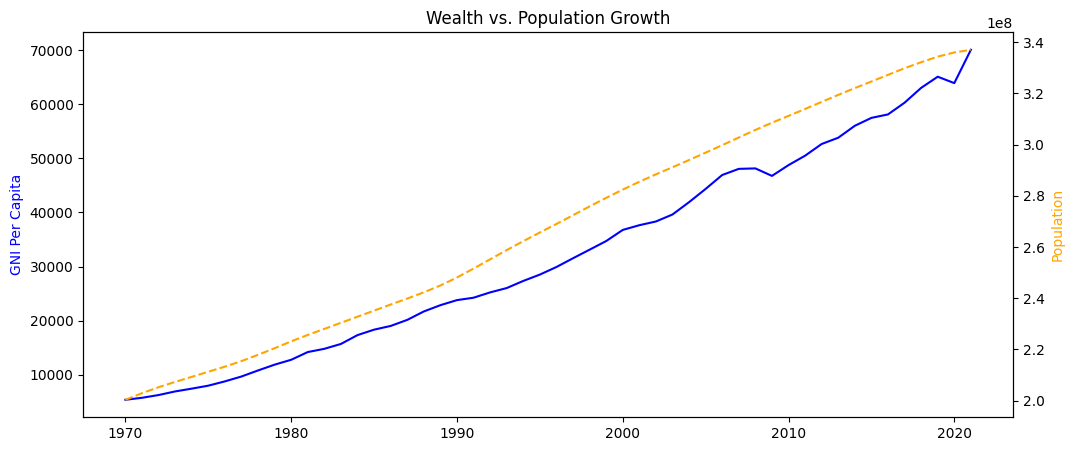

In [93]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(ts_data.index, ts_data['Per capita GNI'], color='blue', label='Per Capita GNI')
ax2.plot(ts_data.index, ts_data['Population'], color='orange', label='Population', linestyle='--')

ax1.set_ylabel('GNI Per Capita', color='blue')
ax2.set_ylabel('Population', color='orange')
plt.title('Wealth vs. Population Growth')
plt.show()

##  Training a Model & Experimental Design

**Aim:** To establish a predictive pipeline by comparing a Classical Machine Learning model (Linear Regression) against an Ensemble Learning model (Random Forest) and also A single tree model to test non-linear rule splits(Decision Tree). We used a chronological time-series split (80% training, 20% testing) instead of a random shuffle to prevent data leakage from the future into the past.

**Interpretation of Results:** The experiment provided a great insight into time-series forecasting algorithms. The results were:

**Linear Regression:** R2 Score of 0.80 and an RMSE of ~$936 Billion.

**Random Forest:** R2 Score of -3.51 (negative) and an RMSE of ~$4.49 Trillion.

**Decision Tree (Tuned):** R2 Score of -3.12 (negative) and an RMSE of ~$4.29 Trillion.

**What this means:** The Linear Regression model performed reasonably well because it learned the mathematical trend of the economic indicators and was able to predict higher values in the future than it saw in the past(extrapolate).

Conversely, both the single Decision Tree and the Random Forest performed poorly. This highlights a known limitation of all tree-based algorithms: they cannot extrapolate outside the range of their training data. Because the GDP in our test set (the most recent years) was higher than the maximum GDP the trees were trained on, both models capped their predictions at the historical maximum and severely under-predicted the true economic growth.



This proves that while Random Forests are incredibly powerful for stationary data, simple Linear Regression or specialized architectures (like LSTMs) are far superior for forecasting strongly trending economic data.

In [95]:
# Prepare Features
features = ['Population', 'GDP_Lag1', 'GDP_5Year_MA', 'Final consumption expenditure']
target = 'Gross Domestic Product (GDP)'

# Drop rows with NaN caused by Lags/Moving Averages
model_df = ts_data[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

# Time-series split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Experiment 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Experiment 2: Random Forest with Hyperparameter Tuning
rf = RandomForestRegressor(random_state=42)
param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 5, 10]}
grid_search = GridSearchCV(rf, param_grid, cv=3)
grid_search.fit(X_train, y_train)
rf_preds = grid_search.best_estimator_.predict(X_test)

# Experiment 3: Decision Tree (Tuned)
dt = DecisionTreeRegressor(random_state=42)
dt_param_grid = {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]}
dt_grid = GridSearchCV(dt, dt_param_grid, cv=3)
dt_grid.fit(X_train, y_train)
dt_preds = dt_grid.best_estimator_.predict(X_test)

# Experiment Table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree (Tuned)', 'Random Forest (Tuned)'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_preds)),
        np.sqrt(mean_squared_error(y_test, dt_preds)),
        np.sqrt(mean_squared_error(y_test, rf_preds))
    ],
    'R2 Score': [
        r2_score(y_test, lr_preds),
        r2_score(y_test, dt_preds),
        r2_score(y_test, rf_preds)
    ]
})

print("Experiment Comparison")
print(results)

Experiment Comparison
                   Model                 RMSE  R2 Score
0      Linear Regression   936,844,313,887.51      0.80
1  Decision Tree (Tuned) 4,297,673,789,388.86     -3.12
2  Random Forest (Tuned) 4,493,962,171,625.39     -3.51
